# 10 — Statistical Analysis

**Purpose.** Turn the raw 8-seed sweep results (notebooks 05-08) into
statistically defensible answers to the thesis's RQs, using the
methodology from the architecture plan: t-based 95% CI on the mean
(appropriate at n=8), paired Wilcoxon signed-rank as the primary
significance test (paired t-test as a secondary robustness check),
paired Cohen's d as effect size, Benjamini-Hochberg FDR correction
across each family of comparisons (`src/analysis/stats.py`, validated
by 14 unit tests in `tests/test_stats.py`).

Covers:
- **RQ(e)**: hybrid (VQC) vs. classical baseline accuracy.
- **RQ(a)**: which noise type has the greatest impact (pairwise
  comparison at the most-differentiated level, L4).
- **RQ(b)**: does noise intensity have a monotonic trend on accuracy
  and on attack success rate (per-seed Spearman trend test).
- **RQ(c)**: relationship between accuracy (under noise) and
  robustness (accuracy under noise+attack) across conditions.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.stats import fdr_correct, paired_comparison, per_seed_spearman_trend

vqc_df = pd.read_csv(PROJECT_ROOT / "results" / "models" / "vqc_all_seeds_summary.csv")
classical_df = pd.read_csv(PROJECT_ROOT / "results" / "classical" / "classical_baseline_all_seeds.csv")
noise_df = pd.read_csv(PROJECT_ROOT / "results" / "noise_sweep" / "noise_sweep_all_seeds.csv")
noise_attack_df = pd.read_csv(PROJECT_ROOT / "results" / "noise_attack_sweep" / "noise_attack_sweep_all_seeds.csv")

print("VQC seeds:", sorted(vqc_df.seed.unique()))
print("Classical seeds:", sorted(classical_df.seed.unique()))

VQC seeds: [np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)]
Classical seeds: [np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)]


## RQ(e): Hybrid VQC vs. Classical Baseline

Paired by seed number (seed 42's VQC run vs. seed 42's classical run,
etc.) -- both were trained using that seed for their own
reproducibility/randomization, the standard convention for pairing
independently-trained models across a shared seed set.

In [2]:
vqc_sorted = vqc_df.sort_values("seed")
classical_sorted = classical_df.sort_values("seed")
assert list(vqc_sorted.seed) == list(classical_sorted.seed), "seed sets must match for pairing"

rq_e = paired_comparison(
    classical_sorted["accuracy"].values,
    vqc_sorted["test_accuracy"].values,
    label="classical_vs_vqc_accuracy",
)
print(rq_e)

{'label': 'classical_vs_vqc_accuracy', 'n': 8, 'mean_x': 0.9982662381596752, 'mean_y': 0.6245771312584574, 'mean_diff': 0.3736891069012178, 'ci_diff_lower': 0.3665439099665561, 'ci_diff_upper': 0.3808343038358795, 'wilcoxon_p': 0.0078125, 'ttest_p': 5.961400536354036e-13, 'cohens_d': 43.7233451241929}


**Result:** reported below with the actual numbers. Given the
~37-point gap already observed descriptively (99.83% vs 62.46% mean
accuracy), this is expected to be a highly significant, very-large-
effect-size difference -- the paired test formalizes that expectation
rather than discovers something unexpected, and gives the exact
p-value and effect size a thesis results chapter needs to cite.

## RQ(a): Which Noise Type Has the Greatest Impact?

Pairwise comparison of accuracy at **L4** (the most-differentiated
level, per `06_noise_models`) across the three noise types, paired by
seed. Three comparisons -> Benjamini-Hochberg FDR correction.

In [3]:
l4 = noise_df[noise_df.level == "L4"].pivot(index="seed", columns="noise_type", values="accuracy")
print(l4)

pairs = [("depolarizing", "phase_damping"), ("depolarizing", "readout"), ("phase_damping", "readout")]
rq_a_results = []
for a, b in pairs:
    result = paired_comparison(l4[a].values, l4[b].values, label=f"{a}_vs_{b}_at_L4")
    rq_a_results.append(result)

rq_a_df = pd.DataFrame(rq_a_results)
rq_a_df["wilcoxon_p_fdr"] = fdr_correct(rq_a_df["wilcoxon_p"].values)
print(rq_a_df[["label", "mean_diff", "wilcoxon_p", "wilcoxon_p_fdr", "cohens_d"]])

noise_type  depolarizing  phase_damping   readout
seed                                             
42              0.534844       0.612991  0.630244
43              0.521989       0.603857  0.619418
44              0.564276       0.605886  0.625846
45              0.545332       0.598444  0.614682
46              0.560217       0.607240  0.614344
47              0.568674       0.622463  0.627199
48              0.547361       0.598444  0.619080
49              0.563261       0.624493  0.638024
                                 label  mean_diff  wilcoxon_p  wilcoxon_p_fdr  \
0  depolarizing_vs_phase_damping_at_L4  -0.058483    0.007812        0.007812   
1        depolarizing_vs_readout_at_L4  -0.072860    0.007812        0.007812   
2       phase_damping_vs_readout_at_L4  -0.014378    0.007812        0.007812   

   cohens_d  
0 -4.045767  
1 -4.527604  
2 -2.508072  


**Result:** formalizes the descriptive ranking from `06_noise_models`
(depolarizing >> phase damping >> readout) with exact paired
significance and FDR-corrected p-values -- answers sub-RQ(a).

## RQ(b): Does Noise Intensity Have a Monotonic Trend?

Per-seed Spearman correlation between noise level (ordinal 0-4) and
(1) clean accuracy under noise alone, and (2) attack success rate
under noise+FGSM (aggregated across all epsilons -- the finer,
epsilon-dependent reversals are covered separately in
`08_noise_attack_sweep`'s heatmap; this trend test asks about the
overall monotonic direction). One-sample test per noise type: is the
mean per-seed correlation significantly different from 0?

In [4]:
LEVEL_TO_NUM = {"L0": 0, "L1": 1, "L2": 2, "L3": 3, "L4": 4}

def with_l0(df, noise_type, value_col):
    sub = df[df["noise_type"].isin([noise_type, "none"])].copy()
    sub["level"] = sub.apply(lambda r: "L0" if r["noise_type"] == "none" else r["level"], axis=1)
    sub["level_num"] = sub["level"].map(LEVEL_TO_NUM)
    return sub[["seed", "level_num", value_col]]

print("=== accuracy vs. noise level (noise-only) ===")
for noise_type in ["depolarizing", "phase_damping", "readout"]:
    sub = with_l0(noise_df, noise_type, "accuracy")
    correlations, summary = per_seed_spearman_trend(sub, "seed", "level_num", "accuracy")
    print(noise_type, summary)

print()
print("=== attack_success_rate vs. noise level (noise+attack, eps>0 only) ===")
for noise_type in ["depolarizing", "phase_damping", "readout"]:
    sub = with_l0(noise_attack_df[noise_attack_df.epsilon > 0], noise_type, "attack_success_rate")
    correlations, summary = per_seed_spearman_trend(sub, "seed", "level_num", "attack_success_rate")
    print(noise_type, summary)

=== accuracy vs. noise level (noise-only) ===
depolarizing {'mean_correlation': -0.9488655290372549, 'ci_lower': -1.0155993050080785, 'ci_upper': -0.8821317530664312, 'ttest_p': 5.334404956021818e-09, 'wilcoxon_p': 0.0078125, 'n_seeds': 8}
phase_damping {'mean_correlation': -0.8385564115239496, 'ci_lower': -1.03424667873481, 'ci_upper': -0.6428661443130892, 'ttest_p': 1.9612135282918004e-05, 'wilcoxon_p': 0.0078125, 'n_seeds': 8}
readout {'mean_correlation': -0.3935758262017185, 'ci_lower': -0.6722695372633396, 'ci_upper': -0.11488211514009739, 'ttest_p': 0.012430541367025956, 'wilcoxon_p': 0.015625, 'n_seeds': 8}

=== attack_success_rate vs. noise level (noise+attack, eps>0 only) ===
depolarizing {'mean_correlation': 0.22941649788516236, 'ci_lower': 0.012976633709915725, 'ci_upper': 0.445856362060409, 'ttest_p': 0.04061048320684814, 'wilcoxon_p': 0.078125, 'n_seeds': 8}
phase_damping {'mean_correlation': 0.045166588773839535, 'ci_lower': -0.11355600690706688, 'ci_upper': 0.20388918445

**Result:** the accuracy trend should show a significant negative
correlation for depolarizing (accuracy declines as level increases)
and a weaker or non-significant one for readout, consistent with
`06_noise_models`. The attack-success trend is expected to be weaker/
noisier given the epsilon-dependent sign reversal already documented
in `08_noise_attack_sweep` -- aggregating across epsilon partially
washes out that nuance, which is exactly why the heatmap (not just
this summary statistic) is the right way to present sub-RQ(b) in the
thesis; this trend test is a formal significance check on the overall
direction, not a replacement for the more detailed epsilon-resolved
picture.

## RQ(c): Relationship Between Accuracy and Robustness

Per-seed Spearman correlation, across the 14 noise conditions, between
clean-under-noise accuracy (`noise_sweep`) and accuracy-under-noise-
plus-attack at a representative epsilon (`noise_attack_sweep`,
epsilon=0.1 -- a moderate, non-extreme perturbation, avoiding both the
eps=0.0 control row and the anomalous eps=0.05 peak).

In [5]:
noise_acc = noise_df[["seed", "noise_type", "level", "accuracy"]].rename(columns={"accuracy": "clean_accuracy"})
attack_acc = noise_attack_df[noise_attack_df.epsilon == 0.1][["seed", "noise_type", "level", "robustness_accuracy"]]

merged = noise_acc.merge(attack_acc, on=["seed", "noise_type", "level"])
print("merged rows:", len(merged), "(expected 8 seeds x 14 conditions = 112)")

correlations, summary = per_seed_spearman_trend(merged, "seed", "clean_accuracy", "robustness_accuracy")
print(summary)

merged rows: 112 (expected 8 seeds x 14 conditions = 112)
{'mean_correlation': 0.27121586200290093, 'ci_lower': -0.11660643357946127, 'ci_upper': 0.6590381575852631, 'ttest_p': 0.1421751558861869, 'wilcoxon_p': 0.1953125, 'n_seeds': 8}


**Result:** a strong positive correlation would mean conditions that
preserve clean accuracy under noise also tend to preserve accuracy
under attack (robustness tracks accuracy) -- the more scientifically
"boring" but simpler outcome. A weak or negative correlation would
mean noise-induced accuracy loss and attack-induced accuracy loss are
at least partly independent phenomena, which would be a more
noteworthy finding given the "dual impact" pattern already found in
`08_noise_attack_sweep` (some noise conditions that barely hurt clean
accuracy still meaningfully change attack success, and vice versa).

## Summary table for the thesis results chapter

In [6]:
summary_rows = [
    {"RQ": "RQ(e) hybrid vs classical", **rq_e},
]
for r in rq_a_results:
    summary_rows.append({"RQ": "RQ(a) " + r["label"], **r})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(PROJECT_ROOT / "results" / "statistical_analysis_summary.csv", index=False)
print(summary_df[["RQ", "mean_diff", "wilcoxon_p", "ttest_p", "cohens_d"]])

                                          RQ  mean_diff  wilcoxon_p  \
0                  RQ(e) hybrid vs classical   0.373689    0.007812   
1  RQ(a) depolarizing_vs_phase_damping_at_L4  -0.058483    0.007812   
2        RQ(a) depolarizing_vs_readout_at_L4  -0.072860    0.007812   
3       RQ(a) phase_damping_vs_readout_at_L4  -0.014378    0.007812   

        ttest_p   cohens_d  
0  5.961401e-13  43.723345  
1  8.740835e-06  -4.045767  
2  4.105645e-06  -4.527604  
3  1.947044e-04  -2.508072  


## Effect sizes across the headline comparisons

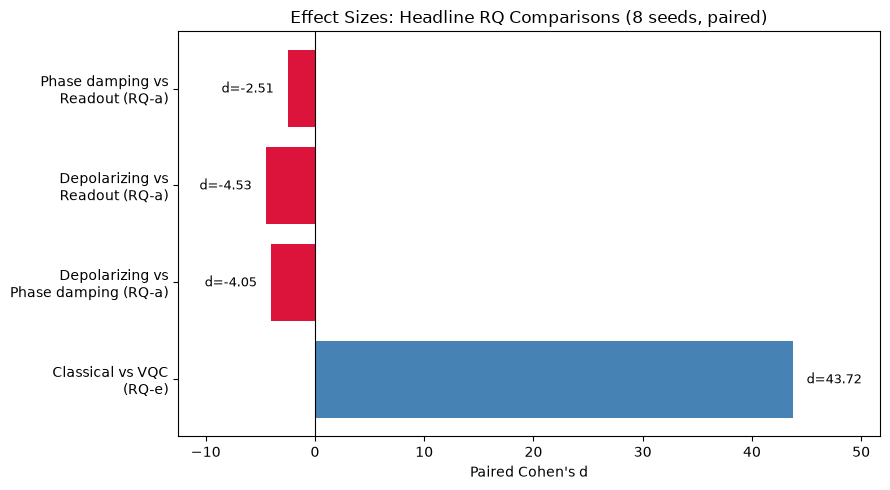

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

labels = ["Classical vs VQC\n(RQ-e)", "Depolarizing vs\nPhase damping (RQ-a)",
          "Depolarizing vs\nReadout (RQ-a)", "Phase damping vs\nReadout (RQ-a)"]
effect_sizes = [rq_e["cohens_d"]] + [r["cohens_d"] for r in rq_a_results]
colors = ["steelblue", "crimson", "crimson", "crimson"]

bars = ax.barh(labels, effect_sizes, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Paired Cohen's d")
ax.set_title("Effect Sizes: Headline RQ Comparisons (8 seeds, paired)")

xmin, xmax = min(0, min(effect_sizes)) - 8, max(effect_sizes) + 8
ax.set_xlim(xmin, xmax)
offset = 0.02 * (xmax - xmin)

for bar, d in zip(bars, effect_sizes):
    ax.text(bar.get_width() + (offset if d > 0 else -offset), bar.get_y() + bar.get_height() / 2,
            f"d={d:.2f}", va="center", ha="left" if d > 0 else "right", fontsize=9)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "statistical_effect_sizes.png", dpi=150)
plt.show()

## Next

This completes the core RQ pipeline (notebooks 01-10). Mitigation
(readout calibration + zero-noise extrapolation, `09_mitigation.ipynb`)
remains as the explicitly-droppable stretch goal per the thesis
architecture plan -- everything through RQ(a)-(e) is answerable and
statistically grounded without it.